### **Description**

This recipe shows how to calculate regional sea ice area and sea ice extent using monthly-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA025 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
Sea ice is a critical component of the climate system owing to its ability to mediate the exchange of heat between the atmosphere and ocean.

Two of the most visible indicators of anthropogenic forcing on the climate system are Arctic and Antarctic sea ice area / extent, where:

* Sea ice area represents the total region covered by sea ice.

* Sea ice extent is the total region with at least some minimum threshold percent sea ice cover, where this threshold is often taken to be 15% for satellite observations.

Observational products typically report total sea ice extent, which gives larger values than sea ice area since:

$$\int \int_A simask(\lambda, \phi)  \ dA > \int \int_A siconc(\lambda, \phi)  \ dA$$

where $siconc(\lambda, \phi) \in [0, 1]$ is the fractional sea ice concentration and $simask$ is given by the indicator function:

$$
simask(siconc_i \geq siconc^*) =
\begin{cases}
1 & \text{if } siconc_i \geq siconc^* \\
0 & \text{otherwise}
\end{cases}
$$

where $siconc^*$ is the threshold sea ice fraction to be considered ice covered.

---

In [1]:
# -- Import required packages -- #
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

**Note:** Although using Dask is not strictly necessary for this simple example using eORCA025, if we wanted to generalise this recipe to eORCA12 or eORCA36 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA025 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [2]:
# Define directory path to ancillary files:
domain_filepath = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca025-jra55v1/domain_cfg"

# Open eORCA025 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_filepath, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 10GB
Dimensions:       (y: 1206, x: 1440, nav_lev: 75)
Coordinates:
  * y             (y) int64 10kB 0 1 2 3 4 5 6 ... 1200 1201 1202 1203 1204 1205
  * x             (x) int64 12kB 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    atlmsk        (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bathy_metry   (y, x) float32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bottom_level  (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1f           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1t           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1u           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
    umaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
    vmaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
Attributes:
    CfgName:    orca
    CfgIndex:   25
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     T
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  08/11/2022 13:15:21 -0000

**Next, we need to import sea ice concentration stored at T-points in a single dataset.**

In [3]:
# Define directory path to model output files:
icemod_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca025-jra55v1/I1m_3d"

# Construct NEMO model T-grid dataset, including sea ice concentration and sea ice volume (m3):
ds_icemod = xr.open_zarr(icemod_url, consolidated=True, chunks={})

ds_icemod

<xarray.Dataset> Size: 321GB
Dimensions:               (time_counter: 577, y: 1206, x: 1440, ncatice: 5,
                           axis_nbounds: 2)
Coordinates:
  * time_counter          (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:...
    time_centered         (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lon               (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
  * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/54)
    albedo                (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfxcndbot             (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfxcndtop             (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfxsensib             (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    isig1                 (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    isig2                 (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                    ...
    utau_ai               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    utau_oi               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    vfxice                (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    vfxsnw                (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    vtau_ai               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    vtau_oi               (time_counter, y, x) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_1m_icemod
    description:  ice variables
    title:        ice variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-07 20:28:41 GMT
    uuid:         b43a126e-39e5-4c6f-92aa-9fde45db2d07

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and icemod variables for the eORCA025 model.**

In [4]:
# Define dictionary of grid datasets defining eORCA025 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "icemod": ds_icemod}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on T-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="T", read_mask=False)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 577, axis_nbounds: 2, ncatice: 5)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:...
│       time_centered         (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│     * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridT
│       Dimensions:               (time_counter: 577, j: 1206, i: 1440, ncatice: 5,
│                                  axis_nbounds: 2, k: 75)
│       Coordinates:
│           time_centered         (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 10kB 1 2 3 4 5 ... 1202 1203 1204 1205 1206
│         * i                     (i) int64 12kB 1 2 3 4 5 ... 1436 1437 1438 1439 1440
│           gphit                 (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamt                 (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/58)
│           albedo                (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           hfxcndbot             (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           hfxcndtop             (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           hfxsensib             (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           isig1                 (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           isig2                 (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           ...                    ...
│           vtau_ai               (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           vtau_oi               (time_counter, j, i) float32 4GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
│           e1t                   (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2t                   (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           tmask                 (k, j, i) bool 130MB dask.array<chunksize=(75, 603, 720), meta=np.ndarray>
│           tmaskutil             (j, i) bool 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│       Attributes:
│           name:         OUTPUT/eORCA025_1m_icemod
│           description:  ice variables
│           title:        ice variables
│           Conventions:  CF-1.6
│           timeStamp:    2024-Dec-07 20:28:41 GMT
│           uuid:         b43a126e-39e5-4c6f-92aa-9fde45db2d07
│           nftype:       T
│           iperio:       True
├── Group: /gridU
│       Dimensions:       (j: 1206, i: 1440, k: 75)
│       Coordinates:
│         * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.438e+03 1.44e+03 1.44e+03
│           gphiu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│       Data variables:
│           

### **Visualising Sea Ice Concentration**

**Now we have constructed our `NEMODataTree`, let's creat a `NEMODataArray` storing the Arctic sea ice concentration for March only:**

Here, we first define a geographical mask using the latitude defined on scalar **T**-points before applying this mask to only the time-slices of the sea ice concentraction (fraction of unity) for March each year.

In [5]:
# Define time_counter mask to select only March outputs:
month = 3
time_counter_mask = nemo['gridT/time_counter'].dt.month.isin([month])

# Define hemisphere mask to select only Northern Hemisphere (>30 N):
gphit_mask = (nemo['gridT/gphit'].data > 30).compute()

# Calculate March Arctic sea ice concentration:
siconc_march = (nemo['gridT/siconc']
                .masked
                .sel(time_counter=time_counter_mask) # Select only March.
                .where(gphit_mask, drop=True) # Select only Arctic.
                )

siconc_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'siconc' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'siconc' (time_counter: 48, j: 396, i: 1440)> Size: 109MB
dask.array<where, shape=(48, 396, 1440), dtype=float32, chunksize=(1, 396, 720), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
  * j              (j) int64 3kB 811 812 813 814 815 ... 1203 1204 1205 1206
  * i              (i) int64 12kB 1 2 3 4 5 6 ... 1435 1436 1437 1438 1439 1440
    gphit          (j, i) float64 5MB 29.73 29.73 29.73 ... 50.07 50.02 50.0
    glamt          (j, i) float64 5MB 73.0 73.25 73.5 73.75 ... 73.0 73.0 73.0
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

**Next, let's visualise the Arctic sea ice concentration climatology for March:**

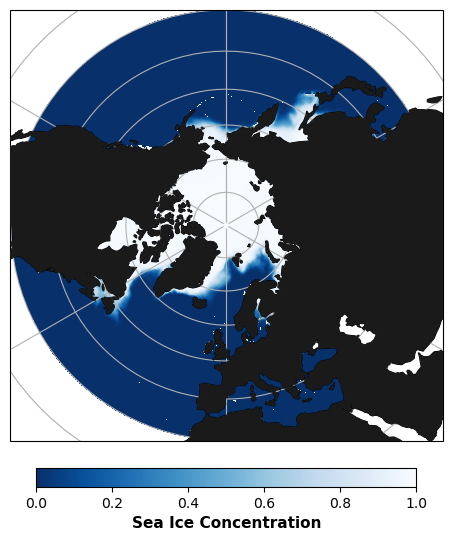

In [6]:
# -- Create a Figure with an North Polar Stereographic projection -- #
fig = plt.figure(figsize=(7, 7))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# Plot eORCA025 JRA55v1 March-mean Arctic sea ice concentration:
c_parent = ax.pcolormesh(siconc_march['glamt'],
                         siconc_march['gphit'],
                         siconc_march.mean(dim='time_counter'), # Average over all March outputs.
                         transform=ccrs.PlateCarree(),
                         cmap="Blues_r", shading="auto",
                         vmin=0, vmax=1,
                         zorder=1)

# Add colorbar with label:
cb = plt.colorbar(c_parent, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("Sea Ice Concentration", fontsize=11, fontweight="bold")


### **Calculating Arctic Sea Ice Area**

**Now we have constructed our `NEMODataTree`, let's calculate the total March sea ice area (`siarea`) for the Arctic each year:**

$$siarea(t) = \sum_{j} \sum_{i} (e_{1t}(j, i) \ . \ e_{2t}(j, i) \ . \ siconc(t, j, i))$$

Given that our sea ice concentration is a fraction of unity, we can calculate the total sea ice area using the `integral()` method to perform a discrete area integral.


In [7]:
# Define conversion factor from m2 to millions km2:
m2_to_million_km2 = 1E-12

# Calcuate Arctic sea ice area [millions km2]:
siarea_march = m2_to_million_km2 * siconc_march.integral(dims=["i", "j"])
siarea_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ij(siconc)' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'integral_ij(siconc)' (time_counter: 48)> Size: 384B
dask.array<mul, shape=(48,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

**Notice that the output above contains dask arrays, so we haven't actually computed the sea ice area time series yet. To do this, we need to call the ``.compute()`` method:**

In [8]:
siarea_march = siarea_march.compute()
siarea_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ij(siconc)' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'integral_ij(siconc)' (time_counter: 48)> Size: 384B
array([15.2408672 , 15.79595013, 15.52007057, 15.67490804, 15.4822803 ,
       15.38406103, 15.53892779, 15.73057268, 15.10191968, 15.09060138,
       15.16780209, 15.33381377, 15.42379346, 14.71695332, 15.18094565,
       14.67146894, 14.76720599, 15.20104239, 15.03428544, 14.55060593,
       14.42182747, 14.77674223, 14.98954958, 14.86408957, 14.63162772,
       14.96846618, 14.81741809, 15.07512074, 14.73251504, 14.31403776,
       14.01130097, 13.99332879, 14.6702956 , 14.55893887, 14.62526484,
       14.00725094, 14.60984041, 14.31873289, 14.11679314, 13.73934657,
       13.90021079, 13.76015308, 13.63476796, 13.71709969, 13.93802755,
       13.91244292, 13.88787505, 13.86517418])
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

### **Calculating Arctic Sea Ice Extent**

**Next we will calculate March sea ice extent from sea ice concentration. This is often used to compare model simulated sea ice to satellite-derived sea ice observations, such as NSIDC, HadISST, OISSTv2 etc.**

To calculate sea ice extent, we must first mask our sea ice concentration field such that any T-point grid cell with a sea ice concentration exceeding a chosen threshold is treated as completely sea ice covered (i.e., `simask=1`), whereas those a sea ice concentration less than the threshold are considered sea ice free (i.e., `simask=0`).

Typically, this threshold is chosen to be 15% sea ice concentration to be consistent with observational data products (e.g., [**NSIDC**](https://nsidc.org/sea-ice-today/about-data)).

Note, often NEMO model `icemod` outputs include sea ice mask variables for a range of common thresholds.


In [9]:
# Define sea ice boolean mask [1: siconc > 15% | 0: siconc <= 15%] for all months:
nemo['gridT']['simask'] = (nemo['gridT/siconc'].data > 0.15)

# Calculate March Arctic sea ice mask:
simask_march = (nemo['gridT/simask']
                .masked
                .sel(time_counter=time_counter_mask) # Select only March.
                .where(gphit_mask, drop=True) # Select only Arctic.
                )

simask_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'simask' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'simask' (time_counter: 48, j: 396, i: 1440)> Size: 219MB
dask.array<where, shape=(48, 396, 1440), dtype=float64, chunksize=(1, 396, 720), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
  * j              (j) int64 3kB 811 812 813 814 815 ... 1203 1204 1205 1206
  * i              (i) int64 12kB 1 2 3 4 5 6 ... 1435 1436 1437 1438 1439 1440
    gphit          (j, i) float64 5MB 29.73 29.73 29.73 ... 50.07 50.02 50.0
    glamt          (j, i) float64 5MB 73.0 73.25 73.5 73.75 ... 73.0 73.0 73.0
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

**Next, let's visualise the Arctic sea ice mask from a single March:**

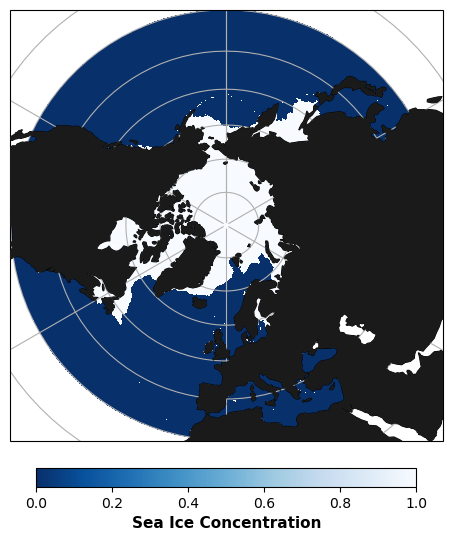

In [10]:
# -- Create a Figure with an North Polar Stereographic projection -- #
fig = plt.figure(figsize=(7, 7))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# Plot eORCA025 JRA55v1 example March Arctic sea ice mask:
c_parent = ax.pcolormesh(simask_march['glamt'],
                         simask_march['gphit'],
                         simask_march.isel(time_counter=0), # Average over all March outputs.,
                         transform=ccrs.PlateCarree(),
                         cmap="Blues_r", shading="auto",
                         vmin=0, vmax=1,
                         zorder=1)

# Add colorbar with label:
cb = plt.colorbar(c_parent, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("Sea Ice Concentration", fontsize=11, fontweight="bold")

**Now we have produced our binary sea ice / ocean mask, let's calculate the total March sea ice extent (`siextent`) for the Arctic each year:**

$$siextent(t) = \sum_{j} \sum_{i} (e_{1t}(j, i) \ . \ e_{2t}(j, i) \ . \ simask(t, j, i))$$

Given that our sea ice mask is defined as either `ocean=0` or `ice=1`, we can similarly calculate the total sea ice extent using the `integral()` method.

In [11]:
# Calcuate Arctic sea ice extent [millions km2]:
siextent_march = m2_to_million_km2 * simask_march.integral(dims=["i", "j"])
siextent_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ij(simask)' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'integral_ij(simask)' (time_counter: 48)> Size: 384B
dask.array<mul, shape=(48,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

**Notice that the output above contains dask arrays, so we haven't actually computed the sea ice area time series yet. To do this, we need to call the ``.compute()`` method:**

In [12]:
siextent_march = siextent_march.compute()
siextent_march

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ij(simask)' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'integral_ij(simask)' (time_counter: 48)> Size: 384B
array([16.32824789, 16.86941318, 16.5183107 , 16.72445344, 16.4576558 ,
       16.29064754, 16.52695254, 16.76295723, 16.22850156, 16.16246814,
       16.23776532, 16.44139358, 16.41876482, 15.75799642, 16.2668418 ,
       15.6035572 , 15.87174656, 16.27217629, 16.04578136, 15.55259182,
       15.56961209, 15.84498984, 16.13352913, 15.90625433, 15.69600352,
       16.00316629, 15.90223515, 16.16833642, 15.87076961, 15.32602473,
       15.06186523, 15.03758909, 15.68691232, 15.56774097, 15.64110223,
       15.05039325, 15.62906747, 15.33490905, 15.12441622, 14.65957986,
       14.86761508, 14.79781814, 14.59909284, 14.76745932, 15.03032672,
       14.86457691, 14.91763625, 14.87652651])
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 384B 1976-03-16T12:00:00 ......
Attributes:
    standard_name:       sea_ice_area_fraction
    long_name:           Sea-ice area fraction
    units:               
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

### **Visualising the evolution of Arctic Sea Ice Area & Extent**

**Finally, let's visualise the results by plotting the time-series of Arctic sea ice area and sea ice extent from 1976-2025 together:**

As expected, we can see that Arctic sea ice extent is always larger than Arcitc sea ice area, but both time series capture almost identical interannual variability.

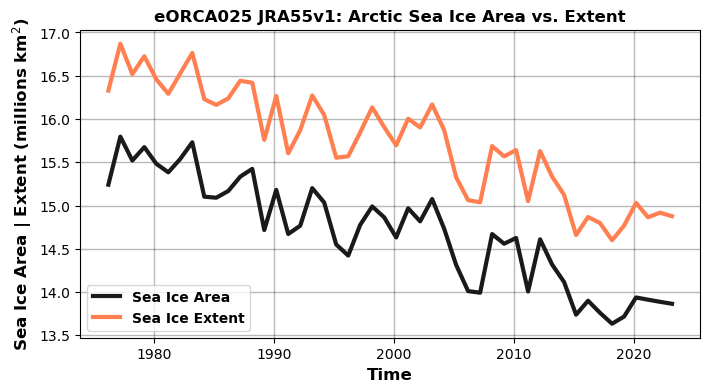

In [13]:
# -- Plotting upper ocean heat content time series for Pacific Ocean -- #
plt.figure(figsize=(8, 4))
plt.grid(visible=True, lw=1, color='0.1', alpha=0.3)

siarea_march.plot(lw=3, color='0.1', label='Sea Ice Area')
siextent_march.plot(lw=3, color='coral', label='Sea Ice Extent')

# Axes labels:
plt.title('eORCA025 JRA55v1: Arctic Sea Ice Area vs. Extent', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('Time', fontdict={'size':12, 'weight':'bold'})
plt.ylabel('Sea Ice Area | Extent (millions km$^{2}$)', fontdict={'size':12, 'weight':'bold'})
plt.legend(loc='lower left', prop={'size':10, 'weight':'bold'})